#  Predicting ERBB2 (HER2) Expression from Copy Number Alterations Using Machine Learning

**Author:** Erick Galdamez Calles
**Course:** DATA 780 – Machine Learning  
**Project Type:** Final Project  

---

##  Overview
This project explores whether gene-level copy number alterations (CNVs) can be used to predict ERBB2 (HER2) gene expression using machine learning models. The goal is to evaluate both predictive performance and biological generalizability across cancer types.

#  Problem Statement

ERBB2 (HER2) is a clinically important oncogene that is frequently amplified in breast cancer. While copy number alterations are known to influence gene expression, it is unclear whether genome-wide CNV patterns can reliably predict ERBB2 expression.

This project aims to:

- Predict ERBB2 expression from genome-wide CNV data
- Compare multiple machine learning models
- Evaluate model generalization across cancer types (breast, ovarian, endometrial)

#  Dataset

Data were obtained from TCGA via the UCSC Xena Browser.

Each dataset includes:
- **Gene-level copy number (GISTIC2)**
- **Gene expression (RNA-seq)**

Cancer types used:
- Breast Cancer (BRCA) – training dataset
- Ovarian Cancer (OV) – external test dataset
- Endometrial Cancer (UCEC) – external test dataset

The target variable is **ERBB2 gene expression**.

In [65]:
import pandas as pd
"""

"""
# File paths (UCSC Xena BRCA datasets)
gistic_copynumber = '/Users/erickgaldamezcalles/Desktop/UCSC Xena datasets/Breast/copy number (gene-level)/TCGA.BRCA.sampleMap_Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes.gz'
tcga_brca_hiseqv2 = '/Users/erickgaldamezcalles/Desktop/UCSC Xena datasets/Breast/gene expression RNAseq/TCGA.BRCA.sampleMap_HiSeqV2'

# Load raw datasets (genes × samples format)
cnv_raw = pd.read_csv(gistic_copynumber, sep="\t", low_memory=False)
expr_raw = pd.read_csv(tcga_brca_hiseqv2, sep="\t", low_memory=False)

print("cnv_raw shape:", cnv_raw.shape)
print("expr_raw shape:", expr_raw.shape)

cnv_raw shape: (24776, 1081)
expr_raw shape: (20530, 1219)


#  Data Preprocessing

The following preprocessing steps were applied:

- Transposed datasets to have samples as rows and genes as features
- Matched samples between CNV and expression data
- Extracted ERBB2 expression as the target variable
- Removed ERBB2 from input features to prevent data leakage
- Selected top variable genes to reduce dimensionality
- Converted all values to numeric format

These steps ensure consistency across datasets and prevent information leakage.

In [66]:
# Convert to samples × genes format
# First column contains gene names → set as index, then transpose
cnv = cnv_raw.set_index(cnv_raw.columns[0]).T
expr = expr_raw.set_index(expr_raw.columns[0]).T

print("cnv shape:", cnv.shape)
print("expr shape:", expr.shape)

# Confirm ERBB2 exists
print("ERBB2 in expr columns?", "ERBB2" in expr.columns)

cnv shape: (1080, 24776)
expr shape: (1218, 20530)
ERBB2 in expr columns? True


In [67]:
# Find shared samples between CNV and expression datasets
common_samples = expr.index.intersection(cnv.index)
print("common samples:", len(common_samples))

common samples: 1078


In [68]:
# Subset both datasets to shared samples
X_brca = cnv.loc[common_samples].copy()
y_brca = expr.loc[common_samples, "ERBB2"].copy()

# Remove ERBB2 from features to prevent leakage
if "ERBB2" in X_brca.columns:
    X_brca = X_brca.drop(columns=["ERBB2"])

# Reduce feature space: keep top 1000 most variable genes
top_genes = X_brca.var().sort_values(ascending=False).head(5000).index
X_brca = X_brca[top_genes]

print("X_brca:", X_brca.shape)
print("y_brca:", y_brca.shape)
print(y_brca.head())

# Check whether GISTIC2 values are discrete
print("Unique values in first 10 genes:")
for gene in X_brca.columns[:10]:
    print(gene, sorted(pd.Series(X_brca[gene]).dropna().unique())[:10])

# Quick global check
all_unique = pd.unique(X_brca.values.ravel())
all_unique = pd.Series(all_unique).dropna().sort_values().unique()
print("Global unique values (up to first 20 shown):", all_unique[:20])

X_brca: (1078, 5000)
y_brca: (1078,)
TCGA-AR-A5QQ-01    10.9073
TCGA-D8-A1JA-01    15.8848
TCGA-BH-A0BQ-01    13.4812
TCGA-BH-A0BT-01    13.9334
TCGA-A8-A06X-01    12.9645
Name: ERBB2, dtype: float64
Unique values in first 10 genes:
ERLIN2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
GPR124 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
ZNF703 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
PROSC [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
RAB11FIP1 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
EIF4EBP1 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
BRF2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
BAG4 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
GOT1L1 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
DDHD2 [np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2)]
Global unique valu

In [69]:
# Check whether GISTIC2 values are discrete
print("Unique values in first 10 genes:")
for gene in X_brca.columns[:10]:
    vals = sorted(pd.Series(X_brca[gene]).dropna().unique().tolist())
    print(gene, vals)

# Quick global check
all_unique = sorted(pd.unique(X_brca.values.ravel()).tolist())
print("Global unique values:", all_unique)

Unique values in first 10 genes:
ERLIN2 [-2, -1, 0, 1, 2]
GPR124 [-2, -1, 0, 1, 2]
ZNF703 [-2, -1, 0, 1, 2]
PROSC [-2, -1, 0, 1, 2]
RAB11FIP1 [-2, -1, 0, 1, 2]
EIF4EBP1 [-2, -1, 0, 1, 2]
BRF2 [-2, -1, 0, 1, 2]
BAG4 [-2, -1, 0, 1, 2]
GOT1L1 [-2, -1, 0, 1, 2]
DDHD2 [-2, -1, 0, 1, 2]
Global unique values: [-2, -1, 0, 1, 2]


In [70]:
# Ensure all values are numeric
X_brca = X_brca.apply(pd.to_numeric, errors="coerce")
y_brca = pd.to_numeric(y_brca, errors="coerce")

#confirm there is no missing/null values in X and y
print("Missing in X:", X_brca.isna().sum().sum())
print("Missing in y:", y_brca.isna().sum())

Missing in X: 0
Missing in y: 0


In [71]:
# Remove samples with missing target values
valid = y_brca.notna()
X_brca = X_brca.loc[valid].fillna(0)
y_brca = y_brca.loc[valid]

#  Train-Test Split

The breast cancer dataset was split into training and testing sets:

- 80% training data
- 20% testing data

This allows evaluation of model performance on unseen data before testing cross-cancer generalization.

In [72]:
# Split into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_brca, y_brca, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(862, 5000) (216, 5000) (862,) (216,)


#  Machine Learning Models

The following models were evaluated:

- **Ridge Regression** (linear baseline)
- **Elastic Net** (regularized linear model)
- **Random Forest** (ensemble tree model)
- **Gradient Boosting** (nonlinear boosting model)

These models were selected to compare linear and nonlinear approaches for predicting ERBB2 expression.

# Evaluation

Model performance was evaluated using:

- **R² (Coefficient of Determination)**  
  Measures how much variance in ERBB2 expression is explained

- **RMSE (Root Mean Squared Error)**  
  Penalizes large prediction errors

- **MAE (Mean Absolute Error)**  
  Average absolute prediction error

These metrics provide complementary perspectives on model performance.

In [73]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print("Ridge alpha:", ridge_model.named_steps["ridge"].alpha)
print("Ridge RMSE:", ridge_rmse)
print("Ridge MAE:", ridge_mae)
print("Ridge R2:", ridge_r2)

Ridge alpha: 1.0
Ridge RMSE: 1.7766633218955439
Ridge MAE: 1.3167948962484426
Ridge R2: -0.4507020558562014


In [83]:
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline


enet_cv = make_pipeline(
    StandardScaler(),
    ElasticNetCV(
        l1_ratio=0.5,
        alphas=np.logspace(-2, 1, 50),
        cv=5,
        max_iter=50000,
        tol=1e-3,
        n_jobs=-1
    )
)

enet_cv.fit(X_train, y_train)
y_pred_elastic = enet_cv.predict(X_test)

elastic_rmse = np.sqrt(mean_squared_error(y_test, y_pred_elastic))
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)
elastic_r2 = r2_score(y_test, y_pred_elastic)

print("Elastic Net RMSE:", elastic_rmse)
print("Elastic Net MAE:", elastic_mae)
print("Elastic Net R2:", elastic_r2)

Elastic Net RMSE: 0.949200105829355
Elastic Net MAE: 0.6597637939852532
Elastic Net R2: 0.5859207109045723


In [84]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest n_estimators:", rf_model.n_estimators)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest n_estimators: 100
Random Forest RMSE: 0.9566256032604683
Random Forest MAE: 0.6411736309872872
Random Forest R2: 0.5794167685039743


In [85]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting n_estimators:", gb_model.n_estimators)
print("Gradient Boosting learning_rate:", gb_model.learning_rate)
print("Gradient Boosting max_depth:", gb_model.max_depth)
print("Gradient Boosting RMSE:", gb_rmse)
print("Gradient Boosting MAE:", gb_mae)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting n_estimators: 300
Gradient Boosting learning_rate: 0.05
Gradient Boosting max_depth: 3
Gradient Boosting RMSE: 0.8987921063769864
Gradient Boosting MAE: 0.6096821436571472
Gradient Boosting R2: 0.6287329115051496


# Results: Breast Cancer (BRCA)

Models were first evaluated on the held-out breast cancer test set.

Key observations:

- Ridge regression performed poorly, indicating weak linear relationships
- Elastic Net improved performance through regularization
- Tree-based models performed best
- Gradient Boosting achieved the highest predictive performance

This suggests that ERBB2 expression depends on nonlinear genomic interactions.

In [195]:
results = pd.DataFrame({
    "Model": ["Ridge", "Elastic Net", "Random Forest", "Gradient Boosting"],
    "R2": [ridge_r2, elastic_r2, rf_r2, gb_r2],
    "RMSE": [ridge_rmse, elastic_rmse, rf_rmse, gb_rmse],
    "MAE": [ridge_mae, elastic_mae, rf_mae, gb_mae]
})

from IPython.display import display

display(results.round(2))

,Model,R2,RMSE,MAE
0,Ridge,-0.45,1.78,1.32
1,Elastic Net,0.59,0.95,0.66
2,Random Forest,0.58,0.96,0.64
3,Gradient Boosting,0.63,0.90,0.61


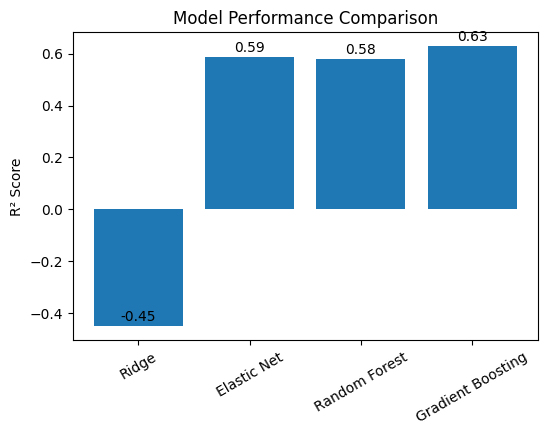

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["R2"])
plt.ylabel("R² Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=30)
for i, v in enumerate(results["R2"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.show()


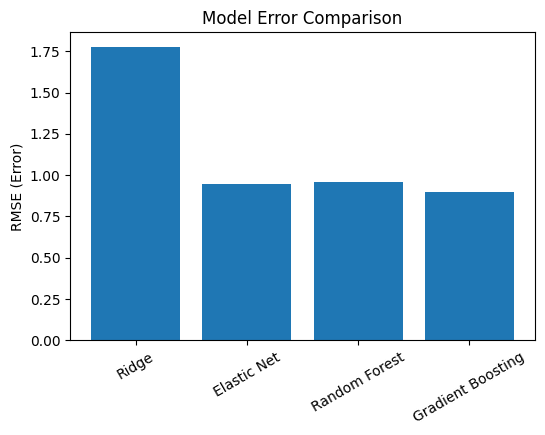

In [415]:
plt.figure(figsize=(6,4))
plt.bar(results["Model"], results["RMSE"])
plt.ylabel("RMSE (Error)")
plt.title("Model Error Comparison")
plt.xticks(rotation=30)
plt.show()

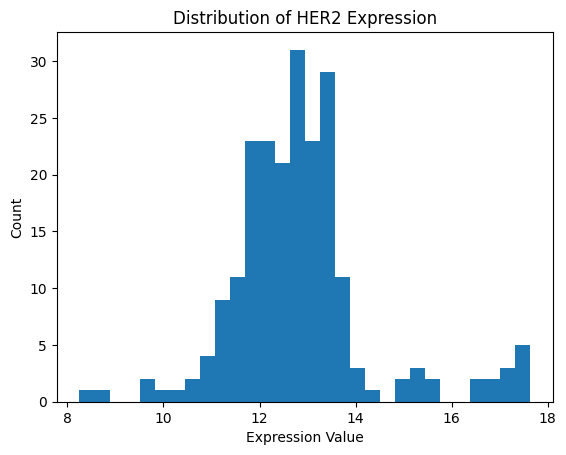

In [416]:
plt.hist(y_test, bins=30)
plt.title("Distribution of HER2 Expression")
plt.xlabel("Expression Value")
plt.ylabel("Count")
plt.show()

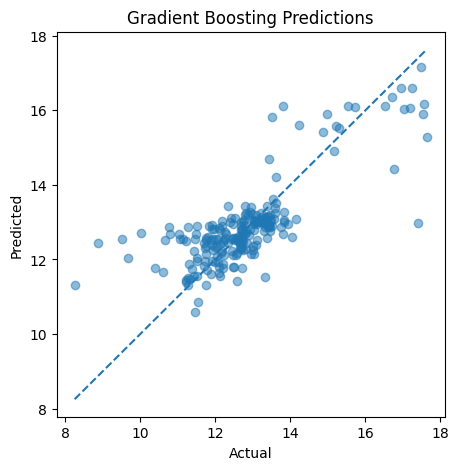

In [430]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred_gb, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Gradient Boosting Predictions")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')
plt.show()

# Feature Importance

Feature importance analysis revealed that:

- Genes located in the HER2 amplicon region were highly predictive
- Co-amplified genes contributed strongly to model performance

This confirms that ERBB2 expression is influenced by regional genomic amplification rather than isolated gene-level effects.

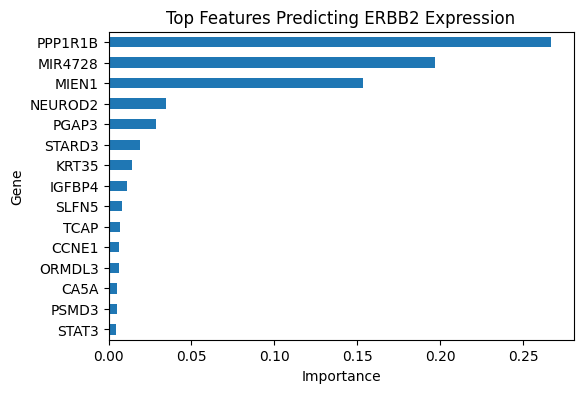

In [456]:
importances = gb_model.feature_importances_
feature_names = X_train.columns

feature_importance = pd.Series(
    gb_model.feature_importances_,
    index=X_brca.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(6,4))
feature_importance.sort_values().plot(kind="barh")
plt.title("Top Features Predicting ERBB2 Expression")
plt.xlabel("Importance")
plt.ylabel("Gene")
plt.show()

# Cross-Cancer Generalization

The trained model was applied to external datasets:

- Ovarian Cancer (OV)
- Endometrial Cancer (UCEC)

Key findings:

- Performance dropped significantly in ovarian cancer
- Moderate performance was observed in endometrial cancer
- This indicates that ERBB2 regulation is tissue-specific

These results highlight the limitations of transferring models across cancer types.

In [457]:
# Ovarian Cancer dataset 
cnv_ov_raw = pd.read_csv('/Users/erickgaldamezcalles/Desktop/UCSC Xena datasets/Ovarian/Copy number (gene level)/TCGA.OV.sampleMap_Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes.gz', sep="\t")
expr_ov_raw = pd.read_csv('/Users/erickgaldamezcalles/Desktop/UCSC Xena datasets/Ovarian/gene expression RNAseq/TCGA.OV.sampleMap_HiSeqV2.gz' , sep="\t")

In [458]:
# transpose
cnv_ov = cnv_ov_raw.set_index(cnv_ov_raw.columns[0]).T
expr_ov = expr_ov_raw.set_index(expr_ov_raw.columns[0]).T

# shared samples
common_ov = expr_ov.index.intersection(cnv_ov.index)

X_ov = cnv_ov.loc[common_ov].copy()
y_ov = expr_ov.loc[common_ov, "ERBB2"].copy()

if "ERBB2" in X_ov.columns:
    X_ov = X_ov.drop(columns=["ERBB2"])

In [459]:
#matching feature space used in Breast cancer dataset training
X_ov = X_ov[X_train.columns]

#Apply numeric cleanup
X_ov = X_ov.apply(pd.to_numeric, errors="coerce").fillna(0)
y_ov = pd.to_numeric(y_ov, errors="coerce")

#checking for data leakage
"ERBB2" in X_ov.columns

X_ov = X_ov[X_train.columns]

Gradient boosting on ovarian cancer dataset

In [ ]:
# test on trained model
y_pred_ov = gb_model.predict(X_ov)

# evaluate
r2_ov = r2_score(y_ov, y_pred_ov)
rmse_ov = np.sqrt(mean_squared_error(y_ov, y_pred_ov))
mae_ov = mean_absolute_error(y_ov, y_pred_ov)

print("OVARIAN RESULTS")
print("R2:", r2_ov)
print("RMSE:", rmse_ov)
print("MAE:", mae_ov)

OVARIAN RESULTS
R2: 0.0910455868833443
RMSE: 0.7725907776106827
MAE: 0.5675489792042858


Endometrial cancer dataset

In [ ]:
# Load data
cnv_ucec_raw = pd.read_csv('/Users/erickgaldamezcalles/Desktop/UCSC Xena datasets/endometrial/copy number (gene level)/TCGA.UCEC.sampleMap_Gistic2_CopyNumber_Gistic2_all_thresholded.by_genes.gz', sep="\t")
expr_ucec_raw = pd.read_csv('/Users/erickgaldamezcalles/Desktop/UCSC Xena datasets/endometrial/gene expression RNAseq/TCGA.UCEC.sampleMap_HiSeqV2.gz', sep="\t")

#transposing dataset
cnv_ucec = cnv_ucec_raw.set_index(cnv_ucec_raw.columns[0]).T
expr_ucec = expr_ucec_raw.set_index(expr_ucec_raw.columns[0]).T

In [462]:
#shared samples
common_ucec = expr_ucec.index.intersection(cnv_ucec.index)

X_ucec = cnv_ucec.loc[common_ucec].copy()
y_ucec = expr_ucec.loc[common_ucec, "ERBB2"].copy()

#removing ERBB2 to avoid leakage
if "ERBB2" in X_ucec.columns:
    X_ucec = X_ucec.drop(columns=["ERBB2"])

#match feature space 
X_ucec = X_ucec[X_train.columns]

#numeric cleanup
X_ucec = X_ucec.apply(pd.to_numeric, errors="coerce").fillna(0)
y_ucec = pd.to_numeric(y_ucec, errors="coerce")


print("ERBB2 in features:", "ERBB2" in X_ucec.columns)
print(X_ucec.shape)
print("Variance of y:", y_ucec.var())

ERBB2 in features: False
(176, 5000)
Variance of y: 1.5171388705139612


In [463]:
# predicting trained model
y_pred_ucec = gb_model.predict(X_ucec)

#evaluate model
r2_ucec = r2_score(y_ucec, y_pred_ucec)
rmse_ucec = np.sqrt(mean_squared_error(y_ucec, y_pred_ucec))
mae_ucec = mean_absolute_error(y_ucec, y_pred_ucec)

print("ENDOMETRIAL (UCEC) RESULTS")
print("R2:", r2_ucec)
print("RMSE:", rmse_ucec)
print("MAE:", mae_ucec)

ENDOMETRIAL (UCEC) RESULTS
R2: 0.4359259931874826
RMSE: 0.9224512036762424
MAE: 0.6586510482696025


# Cross-Cancer Generalization

The trained model was applied to external datasets:

- Ovarian Cancer (OV)
- Endometrial Cancer (UCEC)

Key findings:

- Performance dropped significantly in ovarian cancer
- Moderate performance was observed in endometrial cancer
- This indicates that ERBB2 regulation is tissue-specific

These results highlight the limitations of transferring models across cancer types.

In [471]:
results_test = pd.DataFrame({
    "Dataset": ["Breast", "Ovarian", "Endometrial"],
    "R2": [gb_r2, r2_ov, r2_ucec],
    "RMSE": [gb_rmse, rmse_ov, rmse_ucec],
    "MAE": [gb_mae, mae_ov, mae_ucec]
}).round(3)

display(results_test)

,Dataset,R2,RMSE,MAE
0,Breast,0.629,0.899,0.610
1,Ovarian,0.091,0.773,0.568
2,Endometrial,0.436,0.922,0.659


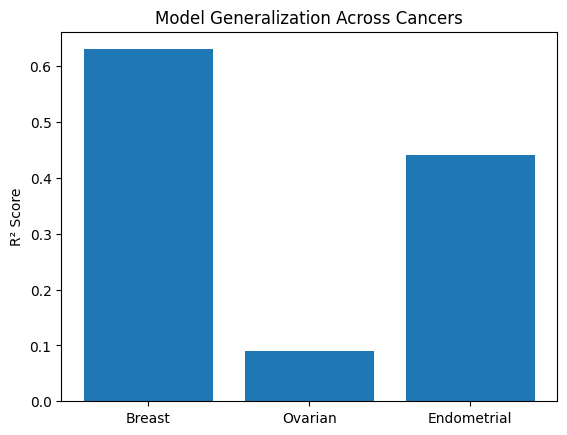

In [472]:
datasets = ["Breast", "Ovarian", "Endometrial"]
r2 = [0.63, 0.09, 0.44]

plt.bar(datasets, r2)
plt.title("Model Generalization Across Cancers")
plt.ylabel("R² Score")
plt.show()

#  Limitations

- Models rely solely on copy number data
- Other regulatory factors (e.g., transcription, epigenetics) are not included
- Dataset size is limited relative to feature space
- Cross-cancer generalization is limited

These factors may affect model performance and generalizability.

# Future Work

Future directions include:

- Extending models to other tumor-associated antigens (e.g., CLDN18.2, MUC16, FOLR1)
- Incorporating multi-omics data (e.g., RNA, methylation)
- Improving cross-cancer generalization
- Identifying shared genomic drivers across cancer types

This would enable a more generalizable framework for predicting protein expression from genomic alterations.

# Conclusion

This study demonstrates that:

- ERBB2 expression can be predicted from CNV data within breast cancer
- Nonlinear models outperform linear approaches
- Predictive relationships do not fully generalize across cancer types

These findings highlight the importance of biological context in machine learning applications to genomics.